# Librerias

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy import constants

# Carga de datos y obtencion de picos

## Mediciones ya promedidadas

Solamente guardo en varibles las mediciones obtenidas.

In [29]:
ruta_helio = 'Mediciones/Helio.pickle'
df = pd.read_pickle(ruta_helio)

Intensidad, err_Intensidad = df['Intensidad'], df['err_Intensidad']
Longitud, err_Longitud = df['Longitud_onda'], df['err_Longitud_onda']

## Picos de cada medición

Utilizando *find_peaks* encuentro los picos correspondientes a las $\lambda$ correspondientes a la absorción/emisión.

In [30]:
Longitudes_absorcion, err_Longitudes_absorcion = [], []
Intensidades_absorcion = []

peaks, _ = find_peaks(Intensidad, prominence = 0.01)
Longitudes_absorcion.append(Longitud[peaks]), err_Longitudes_absorcion.append(err_Longitud[peaks])
Intensidades_absorcion.append(Intensidad[peaks])

# Visualizacion del espectro del hidrogeno

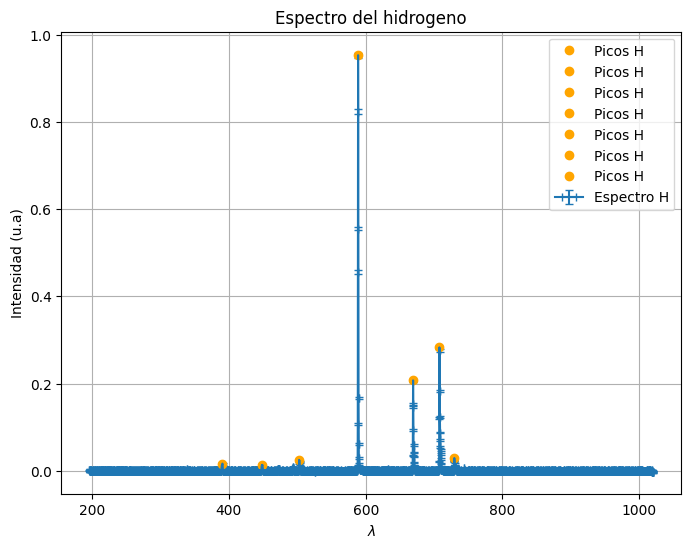

[917     390.461029
1185    448.938385
1428    502.604675
1813    588.874023
2166    669.298645
2333    707.784424
2427    729.570007
Name: Longitud_onda, dtype: float64]


In [31]:
plt.figure(figsize = (8, 6))

plt.errorbar(Longitud, Intensidad, xerr = err_Longitud, yerr = err_Intensidad,
             capsize = 3, label = 'Espectro H') # --> Figura del espectro
plt.plot(Longitudes_absorcion, Intensidades_absorcion, 
         'o', color = 'orange', label = 'Picos H') # --> Marcado de picos
plt.xlabel(r'$\lambda$'), plt.ylabel('Intensidad (u.a)'), plt.title('Espectro del hidrogeno')
plt.grid(), plt.legend(loc = 'upper right')
plt.show()

# Veo cuales son las longitudes de emsion
print(Longitudes_absorcion)

# Armado y ajuste de líneas - Serie Balmer

La lista *datos_experimentales* me lo armo viendo lo de arriba, **a pelo**.

In [32]:
datos_experimentales = [
    {'n1': 2, 'n2': 5, 'longitud_onda': 448},
    {'n1': 2, 'n2': 4, 'longitud_onda': 502},
    {'n1': 2, 'n2': 4, 'longitud_onda': 502},
    {'n1': 2, 'n2': 2, 'longitud_onda': 669},
]

Defino la función de ajuste para obtener $R$ y $\lambda$.

In [33]:
def numero_onda_Rydberg(n1, n2, R):
    """
    Calcula el número de onda según la fórmula de Rydberg
    1/λ = R * (1/n1² - 1/n2²)
    
    Parámetros:
    n1, n2: números cuánticos (n2 > n1)
    R: constante de Rydberg
    """
    return R * (1/n1**2 - 1/n2**2)

def longitud_onda_Rydberg(n1, n2, R):
    """
    Calcula la longitud de onda según la fórmula de Rydberg
    λ = 1 / [R * (1/n1² - 1/n2²)]
    """
    return 1 / (R * (1/n1**2 - 1/n2**2))

## Ajuste

In [34]:
def ajuste_Rydberg(datos):
    """
    Ajusta la constante de Rydberg usando mínimos cuadrados
    """
    # Preparar datos para el ajuste
    n1_list = []
    n2_list = []
    lambda_list = []
    
    for transicion in datos:
        n1_list.append(transicion['n1'])
        n2_list.append(transicion['n2'])
        lambda_list.append(transicion['longitud_onda'])
    
    n1 = np.array(n1_list)
    n2 = np.array(n2_list)
    lambda_exp = np.array(lambda_list) * 1e-9  # Convertir a metros
    
    # Calcular número de onda experimental (1/λ)
    numero_onda_exp = 1 / lambda_exp
    
    # Función objetivo para curve_fit
    def funcion_ajuste(n1_n2, R):
        n1 = n1_n2[0]
        n2 = n1_n2[1]
        return R * (1/n1**2 - 1/n2**2)
    
    # Ajustar parámetros
    parametros_iniciales = [1.0e7]  # Valor inicial para R
    parametros_optimos, covarianza = curve_fit(
        funcion_ajuste, 
        [n1, n2], 
        numero_onda_exp, 
        p0=parametros_iniciales
    )
    
    R_ajustado = parametros_optimos[0]
    error_R = np.sqrt(covarianza[0, 0])
    
    return R_ajustado, error_R

# Calcular R usando el método de ajuste
R_ajustado, error_R = ajuste_Rydberg(datos_experimentales)
print(f"Constante de Rydberg ajustada: {R_ajustado:.4e} ± {error_R:.4e} m⁻¹")
print(f"Valor teórico: {constants.Rydberg:.4e} m⁻¹")

Constante de Rydberg ajustada: 1.0626e+07 ± 2.5514e+06 m⁻¹
Valor teórico: 1.0974e+07 m⁻¹
